# Customer Segmentation using K-Means Clustering
**Objective:** Segment customers based on their purchasing behavior using clustering techniques.

**Dataset:** [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) (Kaggle) — 200 customers with Gender, Age, Annual Income, and Spending Score.

**Tools:** Python (Pandas, Scikit-Learn, Matplotlib)

## Step 0: Upload Your Data File

Run the cell below. If you're on **Google Colab**, an upload dialog will pop up immediately.
If you're on **local Jupyter/JupyterLab**, an upload button will appear — click it, choose your
CSV (e.g. `Mall_Customers.csv`), then run the next cell to finish loading it.

In [1]:
import os

DATA_FILENAME = None

# 1) Google Colab
try:
    from google.colab import files
    print("Please choose your customer data CSV file to upload...")
    _uploaded = files.upload()
    if _uploaded:
        DATA_FILENAME = list(_uploaded.keys())[0]
        with open(DATA_FILENAME, 'wb') as f:
            f.write(_uploaded[DATA_FILENAME])
        print(f"Uploaded: {DATA_FILENAME}")
except ImportError:
    pass

# 2) Local Jupyter/JupyterLab - show an upload widget
if DATA_FILENAME is None:
    try:
        import ipywidgets as widgets
        from IPython.display import display

        upload_widget = widgets.FileUpload(accept='.csv', multiple=False, description='Upload CSV')
        display(upload_widget)
        print("Click 'Upload CSV' above, select your file, then run the next cell.")
    except ImportError:
        print("ipywidgets not available. Place your CSV in this notebook's folder, "
              "then run the next cell (it will auto-detect it).")

FileUpload(value=(), accept='.csv', description='Upload CSV')

Click 'Upload CSV' above, select your file, then run the next cell.


In [2]:
# Run this AFTER uploading above (safe to run even if the Colab upload already worked)
if DATA_FILENAME is None:
    try:
        val = upload_widget.value
        if val:
            item = list(val.values())[0] if isinstance(val, dict) else val[0]
            DATA_FILENAME = item['metadata']['name'] if 'metadata' in item else item['name']
            content = item['content']
            with open(DATA_FILENAME, 'wb') as f:
                f.write(content.tobytes() if hasattr(content, 'tobytes') else content)
            print(f"Uploaded: {DATA_FILENAME}")
    except NameError:
        pass

if DATA_FILENAME is None:
    # Fall back to a CSV already sitting in this folder
    _csvs = [f for f in os.listdir('.') if f.lower().endswith('.csv')]
    if _csvs:
        DATA_FILENAME = _csvs[0]
        print(f"No upload detected - using existing file found in folder: {DATA_FILENAME}")
    else:
        DATA_FILENAME = input("No file uploaded and none found in folder. Enter the path to your CSV: ").strip()

print("Using data file:", DATA_FILENAME)

No upload detected - using existing file found in folder: Mall_Customers.csv
Using data file: Mall_Customers.csv


## Step 1: Load & Explore the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(DATA_FILENAME)
print('Shape:', df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
df.describe()

Dtypes:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0



,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 2: Clean & Prepare the Data

- Standardize column names for easier access
- Confirm no missing values or duplicates need handling
- Encode `Gender` numerically for later use in profiling

In [5]:
df.columns = df.columns.str.strip()
rename_map = {}
for c in df.columns:
    if 'income' in c.lower():
        rename_map[c] = 'Annual_Income'
    elif 'spending' in c.lower():
        rename_map[c] = 'Spending_Score'
    elif c.lower() == 'age':
        rename_map[c] = 'Age'
    elif c.lower() == 'gender':
        rename_map[c] = 'Gender'
    elif 'customerid' in c.lower().replace(' ', ''):
        rename_map[c] = 'CustomerID'
df = df.rename(columns=rename_map)

df = df.drop_duplicates()
df['Gender_Code'] = df['Gender'].map({'Male': 0, 'Female': 1})

print('Cleaned columns:', list(df.columns))
df.head()

Cleaned columns: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score', 'Gender_Code']


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Code
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


## Step 3: Exploratory Data Analysis

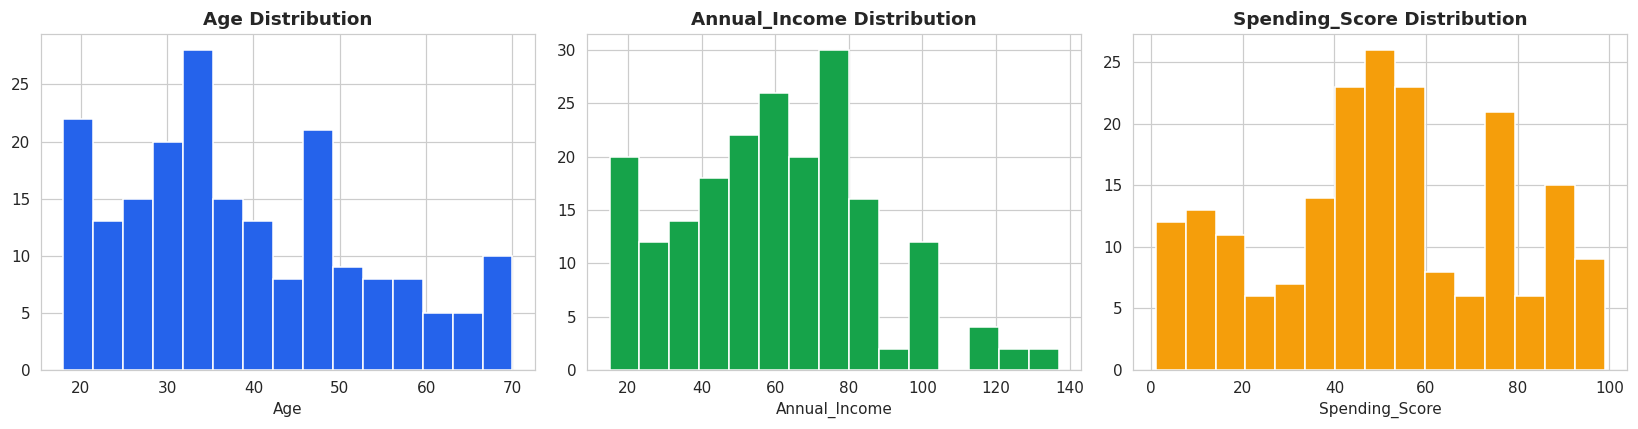

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Age', 'Annual_Income', 'Spending_Score'],
                           ['#2563eb', '#16a34a', '#f59e0b']):
    ax.hist(df[col], bins=15, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

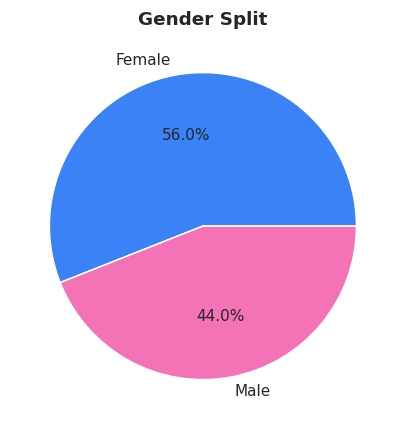

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
gender_counts = df['Gender'].value_counts()
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=['#3b82f6', '#f472b6'])
ax.set_title('Gender Split', fontweight='bold')
plt.tight_layout()
plt.show()

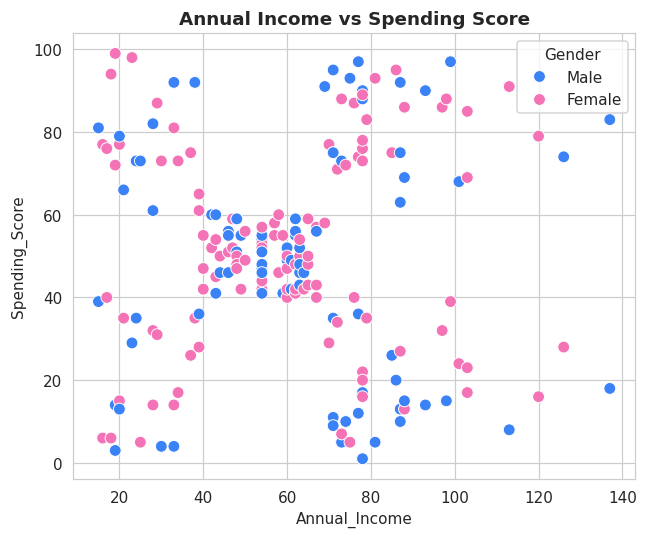

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Gender',
                 palette={'Male': '#3b82f6', 'Female': '#f472b6'}, ax=ax, s=60)
ax.set_title('Annual Income vs Spending Score', fontweight='bold')
plt.tight_layout()
plt.show()

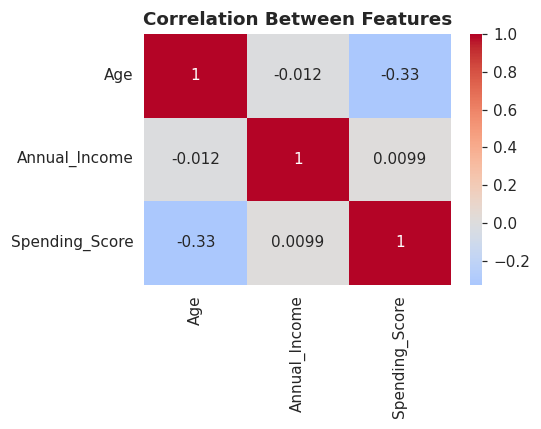

In [9]:
corr = df[['Age', 'Annual_Income', 'Spending_Score']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Between Features', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Feature Selection & Scaling

We'll cluster on **Annual Income** and **Spending Score** — the two variables that most directly
capture purchasing *behavior* (the task's focus), and that also let us visualize clusters cleanly
in 2D. Features are scaled since K-Means is distance-based and income/spending-score are on
different scales.

In [10]:
from sklearn.preprocessing import StandardScaler

features = df[['Annual_Income', 'Spending_Score']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print('Scaled feature sample:')
print(features_scaled[:5])

Scaled feature sample:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## Step 5: Find the Optimal Number of Clusters

Using the **Elbow Method** (within-cluster sum of squares) and the **Silhouette Score** to pick
a defensible value of *k*.

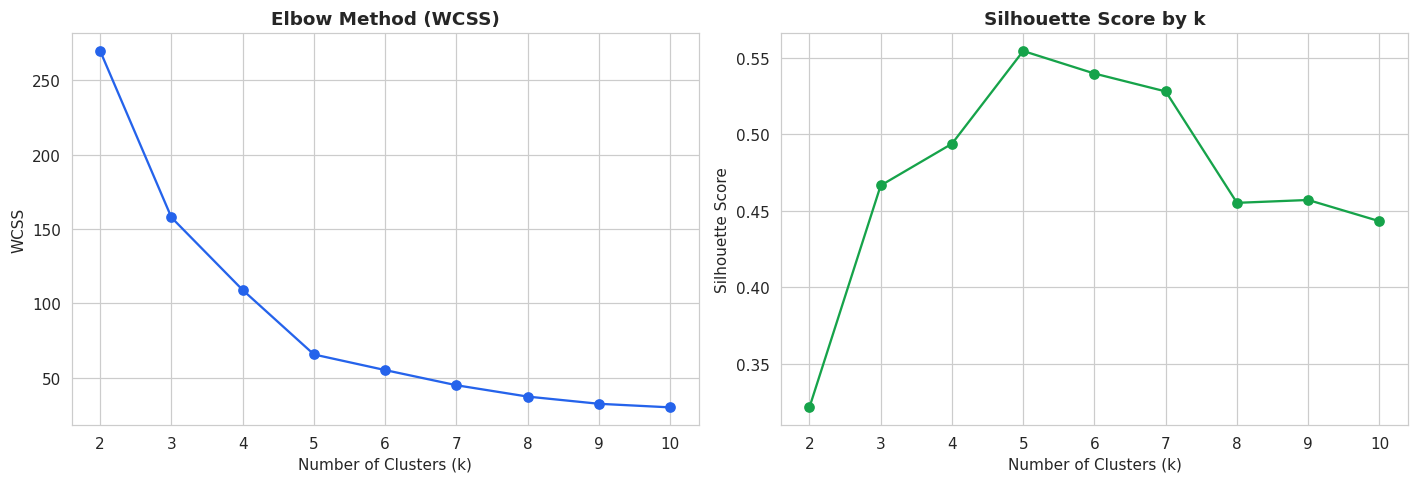

Silhouette score suggests k = 5 (score = 0.555)
WCSS values: [269.7, 157.7, 108.9, 65.6, 55.1, 44.9, 37.2, 32.4, 30.0]


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(features_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), wcss, marker='o', color='#2563eb')
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('WCSS')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#16a34a')
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(sil_scores))]
print(f'Silhouette score suggests k = {best_k_by_silhouette} (score = {max(sil_scores):.3f})')
print('WCSS values:', [round(w, 1) for w in wcss])

Both the elbow "bend" and the silhouette score point to **k = 5** for this dataset — a
well-known result for the Mall Customers data, since the Income vs. Spending Score scatter plot
visibly shows five natural groupings.

## Step 6: Apply K-Means Clustering

In [12]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(features_scaled)

centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

print(f'Clustered {len(df)} customers into {OPTIMAL_K} segments.')
df['Cluster'].value_counts().sort_index()

Clustered 200 customers into 5 segments.


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

## Step 7: Visualize the Clusters

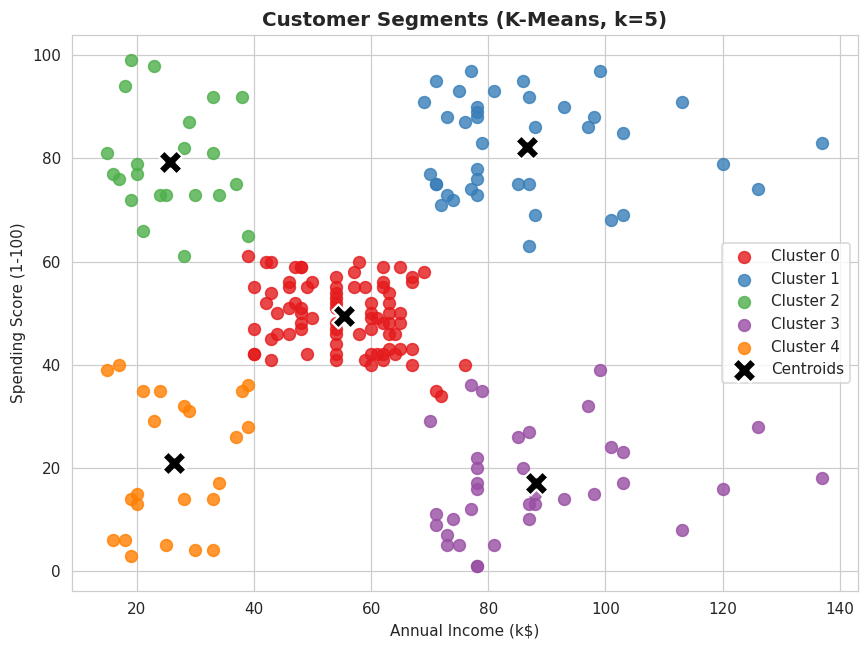

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette('Set1', OPTIMAL_K)

for c in range(OPTIMAL_K):
    subset = df[df['Cluster'] == c]
    ax.scatter(subset['Annual_Income'], subset['Spending_Score'],
               s=60, color=palette[c], label=f'Cluster {c}', alpha=0.8)

ax.scatter(centroids[:, 0], centroids[:, 1], s=250, c='black', marker='X',
           label='Centroids', edgecolor='white', linewidth=1.5)

ax.set_title('Customer Segments (K-Means, k=5)', fontsize=13, fontweight='bold')
ax.set_xlabel('Annual Income (k$)'); ax.set_ylabel('Spending Score (1-100)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 8: Profile Each Segment

In [14]:
profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Pct_Female=('Gender_Code', 'mean')
).round(1)
profile['Pct_Female'] = (profile['Pct_Female'] * 100).round(0)
profile

,Count,Avg_Age,Avg_Income,Avg_Spending,Pct_Female
Cluster,,,,,
0,81,42.7,55.3,49.5,60.0
1,39,32.7,86.5,82.1,50.0
2,22,25.3,25.7,79.4,60.0
3,35,41.1,88.2,17.1,50.0
4,23,45.2,26.3,20.9,60.0


In [15]:
# Human-readable labels: compare each cluster's average to the OVERALL customer base
# (not to other clusters), so a cluster near the dataset average is correctly called "Average"
income_mean, income_std = df['Annual_Income'].mean(), df['Annual_Income'].std()
spend_mean, spend_std = df['Spending_Score'].mean(), df['Spending_Score'].std()
margin = 0.3  # fraction of a standard deviation treated as "near the mean"

def bucket(value, mean, std):
    if value > mean + margin * std:
        return 'High'
    elif value < mean - margin * std:
        return 'Low'
    return 'Mid'

income_bucket = profile['Avg_Income'].apply(lambda v: bucket(v, income_mean, income_std))
spend_bucket = profile['Avg_Spending'].apply(lambda v: bucket(v, spend_mean, spend_std))

label_map = {
    ('High', 'High'): 'High Income, High Spending (Target)',
    ('High', 'Low'):  'High Income, Low Spending (Careful)',
    ('Low', 'High'):  'Low Income, High Spending (Impulsive)',
    ('Low', 'Low'):   'Low Income, Low Spending (Budget)',
}
profile['Segment_Label'] = [
    label_map.get((i, s), 'Average Income, Average Spending (Standard)')
    for i, s in zip(income_bucket, spend_bucket)
]
profile

,Count,Avg_Age,Avg_Income,Avg_Spending,Pct_Female,Segment_Label
Cluster,,,,,,
0,81,42.7,55.3,49.5,60.0,"Average Income, Average Spending (Standard)"
1,39,32.7,86.5,82.1,50.0,"High Income, High Spending (Target)"
2,22,25.3,25.7,79.4,60.0,"Low Income, High Spending (Impulsive)"
3,35,41.1,88.2,17.1,50.0,"High Income, Low Spending (Careful)"
4,23,45.2,26.3,20.9,60.0,"Low Income, Low Spending (Budget)"


## Step 9: Save the Segmented Dataset

In [16]:
output_file = 'customer_segments_output.csv'
df.to_csv(output_file, index=False)
print(f'Saved clustered dataset to {output_file}')
df.head()

Saved clustered dataset to customer_segments_output.csv


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Code,Cluster
0,1,Male,19,15,39,0,4
1,2,Male,21,15,81,0,2
2,3,Female,20,16,6,1,4
3,4,Female,23,16,77,1,2
4,5,Female,31,17,40,1,4


## Step 10: Key Insights & Recommendations

**Optimal clusters:** k = 5, confirmed by both the elbow method and silhouette score.

**Segment profiles** (see Step 8 table for exact numbers):
- **High Income, High Spending** — the most valuable segment; prioritize loyalty programs and premium offers.
- **High Income, Low Spending** — high potential but currently under-engaged; targeted promotions could unlock more spend.
- **Low Income, High Spending** — price-sensitive but enthusiastic buyers; good targets for discounts, bundles, or installment offers.
- **Low Income, Low Spending** — least profitable segment; low priority for marketing spend.
- **Average Income, Average Spending** — the broad middle; general marketing campaigns work well here.

**Recommendations:**
1. Focus premium marketing budget on the **High Income, High Spending** segment — they deliver the best ROI.
2. Design targeted campaigns (e.g., personalized offers) to shift the **High Income, Low Spending** group toward more purchases.
3. Use discount-driven promotions for the **Low Income, High Spending** segment to sustain their engagement without over-relying on markdowns.
4. Deprioritize heavy marketing spend on the **Low Income, Low Spending** segment relative to the others.